# Geographic Accessibility To Stroke Care: Exploratory Data Analysis

In this notebook, we would like to answer the following question: **How geographically accessible is stroke care in the NY-NJ-CT area?**

We have four main variables that address geographic accessibility:
* Estimated drive time to nearest **basic** stroke center
* Estimated drive time to nearest **advanced** stroke center
* Distance to nearest **basic** stroke center
* Distance to nearest **advanced** stroke center

Thus, we are essentially looking at these two indicators of geographic access to stroke care:

* **Access to basic care** - this is a measure of a stroke patient's access to **life-preserving** care, such as rapid diagnosis and acute stroke treatment. It is extremely important for an individual at risk to live within an hour of these type of facilities, as the care that they can provide is **time-sensitive**. Care provided at these facilities, such as clot-busting medications, must be administered within hours.
* **Access to advanced care** - this is a measure of a stroke patient's access to **advanced** care, such as surgery and treatment of more severe, complex strokes such as hemorrhagic strokes (also known as brain hemorrhages). For a patient who has suffered a more complex and/or severe stroke, they are significantly more likely to make a full or partial recovery if they are treated at one of these advanced type of facilities.


## Data Description

The geographic accessibility dataset contains county-level measures of access to certified stroke centers across New York, New Jersey, and Connecticut. Accessibility is quantified using both estimated driving time along the road network and straight-line (geodesic) distance to the nearest Basic and Advanced Stroke Centers. These variables serve as the primary components of the Geographic Accessibility Index (GAI).

| Variable | Type | Description |
|----------|------|-------------|
| **fips** | Categorical | Five-digit Federal Information Processing Standards (FIPS) code uniquely identifying each county. This variable is used to merge geographic accessibility measures with demographic, socioeconomic, and health datasets. |
| **county** | Categorical | Name of the county in which accessibility is evaluated. Accessibility measures are calculated from the county population center. |
| **state** | Categorical | State in which the county is located (New York, New Jersey, or Connecticut). This variable is used for state-level comparisons and summary statistics. |
| **drive_time_min** | Continuous | Estimated driving time (minutes) from the county population center to the nearest **Basic Stroke Center** using the OpenRouteService road network. Lower values indicate greater accessibility to primary stroke care. |
| **drive_time_advanced** | Continuous | Estimated driving time (minutes) from the county population center to the nearest **Advanced Stroke Center** using the OpenRouteService road network. This variable represents accessibility to advanced stroke treatment services. |
| **nearest_stroke_distance** | Continuous | Straight-line (geodesic) distance from the county population center to the nearest **Basic Stroke Center**. This variable measures geographic proximity independent of the transportation network. |
| **nearest_stroke_distance_advanced** | Continuous | Straight-line (geodesic) distance from the county population center to the nearest **Advanced Stroke Center**. This variable represents geographic proximity to advanced stroke care facilities. |


### Type of Stroke Centers

**Basic** - Stroke centers classified as basic include primary stroke centers and acute stroke centers.

* Acute Stroke Center: Specialized hospital or emergency center designed to rapidly diagnose, triage, and treat emergency stroke patiets. The primary goal of these facilities are to minimize brain damage through immediate evaluation and time-critical medical interventions.
* Primary Stroke Center: Designed to provide highly specialized, rapid care for stroke patients. Essentially, they are a step above acute stroke centers and generally have better resources and staff to diagnose and treat acute strokes as quickly as possible with the main goal of minimizing brain damage and stabilizing patients through treatments such as clot-busting medications.

**Advanced** - Stroke centers classified as advanced include thrombectomy-capable stroke centers and comprehensive stroke centers.

* Thrombectomy-Capable Stroke Center: Specialized center that is certified to perform emergency mechanical thrombectomy, which is a procedure that physically removes large blood clots from blocked brain vessels. These centers provide 24/7 care and act as a bridge between primary and comprehensive stroke centers. Oftentimes, these centers are crucial in rural areas where access to comprehensive stroke centers is extremely limited and a patient needs to be transferred to a facility that provides this type of surgery.
* Comprehensive Stroke Center: Specialized center equipped with the highest level of specialized medical care to diagnose and treat the most complex and life-threatening stroke cases. 

### Interpretation of Accessibility Variables

The four accessibility variables describe two complementary aspects of geographic access to stroke care:

- **Driving Time:** Represents travel time along the road network and reflects the estimated time required for transportation to the nearest certified stroke center.
- **Geodesic Distance:** Represents the shortest straight-line distance between the county population center and the nearest stroke center, providing a measure of physical proximity independent of roadway characteristics.

Lower values for both driving time and distance indicate greater geographic accessibility to stroke care.

### Geographic Accessibility Components

The Geographic Accessibility Index (GAI) will be constructed using four accessibility measures:

- Estimated driving time to the nearest **Basic Stroke Center**
- Estimated driving time to the nearest **Advanced Stroke Center**
- Straight-line distance to the nearest **Basic Stroke Center**
- Straight-line distance to the nearest **Advanced Stroke Center**

These variables capture complementary dimensions of spatial accessibility and will be standardized prior to being combined into a composite Geographic Accessibility Index.

## Loading Data from SQLite Database

In [15]:
# Importing neccessary libraries
import sqlite3
import pandas as pd

In [41]:
# Connecting to the database
con = sqlite3.connect("data/stroke_burden.db")

In [61]:
# Loading only the variables neccessary for geographic accessibility EDA
geo = pd.read_sql("""
SELECT
    c.fips,
    c.county,
    c.state,
    m.acute_stroke_mortality_per_100k,
    g.drive_time_min,
    g.drive_time_advanced,
    g.nearest_stroke_distance,
    g.nearest_stroke_distance_advanced
FROM counties AS c
INNER JOIN mortality AS m
ON c.fips = m.fips
INNER JOIN geographic AS g
ON c.fips = g.fips
""", con)

In [63]:
geo.head()

,fips,county,state,acute_stroke_mortality_per_100k,drive_time_min,drive_time_advanced,nearest_stroke_distance,nearest_stroke_distance_advanced
0,36001,Albany,NY,11.60,8.529333,9.723500,1.866161,2.682031
1,36003,Allegany,NY,15.49,18.045833,108.157167,8.146286,58.838805
2,36005,Bronx,NY,9.19,3.220333,7.875333,0.553716,2.150074
3,36007,Broome,NY,16.26,5.427167,5.232500,1.939937,1.247960
4,36009,Cattaraugus,NY,17.56,42.899833,76.188667,13.124613,44.350162


## Data Overview

In this section, we will show the dimensions, data types, presence of missing values, and summary statistics.

### Data Shape

In [71]:
geo.shape

(91, 8)

The dataset contains 8 columns for 91 counties. 

### Data Types

In [75]:
geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   fips                              91 non-null     object 
 1   county                            91 non-null     object 
 2   state                             91 non-null     object 
 3   acute_stroke_mortality_per_100k   91 non-null     float64
 4   drive_time_min                    91 non-null     float64
 5   drive_time_advanced               91 non-null     float64
 6   nearest_stroke_distance           91 non-null     float64
 7   nearest_stroke_distance_advanced  91 non-null     float64
dtypes: float64(5), object(3)
memory usage: 5.8+ KB


The descriptive columns (fips, county, and state) are stored as objects, while the variable columns are stored as double-precision floating-point decimals. 

### Missing Values

In [79]:
geo.isna().sum()

fips                                0
county                              0
state                               0
acute_stroke_mortality_per_100k     0
drive_time_min                      0
drive_time_advanced                 0
nearest_stroke_distance             0
nearest_stroke_distance_advanced    0
dtype: int64

There are no missing values in our dataset that we have constructed.

### Summary Statistics

In [83]:
geo.describe().T

,count,mean,std,min,25%,50%,75%,max
acute_stroke_mortality_per_100k,91.0,14.952857,4.103071,6.940000,11.995000,14.710000,17.800000,28.500000
drive_time_min,91.0,23.490692,20.970986,1.414167,8.512583,16.995000,32.796250,107.346000
drive_time_advanced,91.0,46.846607,39.983619,2.517500,17.679000,40.791833,67.252000,247.279000
nearest_stroke_distance,91.0,10.411264,12.784336,0.238630,2.334842,5.972280,13.682413,70.946164
nearest_stroke_distance_advanced,91.0,25.627527,26.366554,0.348350,5.347346,21.505771,35.660973,140.520928


Some notable values include:
* Median estimated drive time to nearest basic stroke center: 17 minutes
* Median estimated drive time to nearest advanced stroke center: 41 minutes
* Median travel distance to nearest basic stroke center: 5.97 miles
* Median travel distance to nearest advanced stroke center: 21.5 miles

Note that there is a very large range in estimated travel time to the nearest advanced stroke center. There is also a huge difference between the 75th percentile and the max value, indicating that there are a few large outliers where getting to an advanced stroke center in a timely manner is nearly impossible.

## Distribution of Geographic Accessibility

In this section, we would like to answer the following question: **What does accessibility look like across all counties?**

In [116]:
# Importing necessary libraries

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [193]:
# Creating color-blind friendly color palette

palette = {
    "basic": "#4CC9F0",
    "advanced": "#7209B7",
    "distance": "#3A0CA3",
    "advanced_distance": "#2A9D8F",
    "mortality": "#F72585"
}

### Histograms of Geographic Access Variables

In [174]:
# Creating function to plot histogram of geographic access variables

def plot_histogram(
    data,
    column,
    color,
    title,
    xlabel,
    bins=18
):
    """
    Creates a publication-quality histogram with a KDE curve.
    """

    mean = data[column].mean()
    median = data[column].median()
    std = data[column].std()
    minimum = data[column].min()
    maximum = data[column].max()

    fig, ax = plt.subplots(
        figsize=(7, 5),
        facecolor="#F7F7F7"
    )

    ax.set_facecolor("#FAFAFA")

    # Histogram + KDE
    
    sns.histplot(
        data=data,
        x=column,
        bins=bins,
        kde=True,
        color=color,
        edgecolor="white",
        linewidth=1.3,
        alpha=0.85,
        ax=ax
    )

    # Mean
    
    ax.axvline(
        mean,
        color="black",
        linestyle="--",
        linewidth=2,
        label=f"Mean = {mean:.2f}"
    )

    # Median
    
    ax.axvline(
        median,
        color="#F72585",
        linestyle="-",
        linewidth=2,
        label=f"Median = {median:.2f}"
    )

    # Grid
    
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.5,
        color="lightgray"
    )

    # Remove unnecessary borders
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Labels
    
    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        pad=18
    )

    ax.set_xlabel(
        xlabel,
        fontsize=14
    )

    ax.set_ylabel(
        "Number of Counties",
        fontsize=14
    )

    ax.tick_params(
        labelsize=12
    )

    # Sample size

    stats_text = (
    f"n = {len(data)}\n"
    f"Mean = {mean:.2f}\n"
    f"Median = {median:.2f}\n"
    f"SD = {std:.2f}\n"
    f"Range = {minimum:.2f} – {maximum:.2f}"
    )
    
    ax.text(
    0.98,
    0.98,
    stats_text,
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="lightgray",
        boxstyle="round,pad=0.4",
        alpha=0.95
        )
    )

    # Legend
    
    ax.legend(
        frameon=True,
        facecolor="white",
        edgecolor="lightgray",
        fontsize=11
    )

    plt.tight_layout()
    plt.show()

#### Estimated Drive Time to Nearest Basic Stroke Center

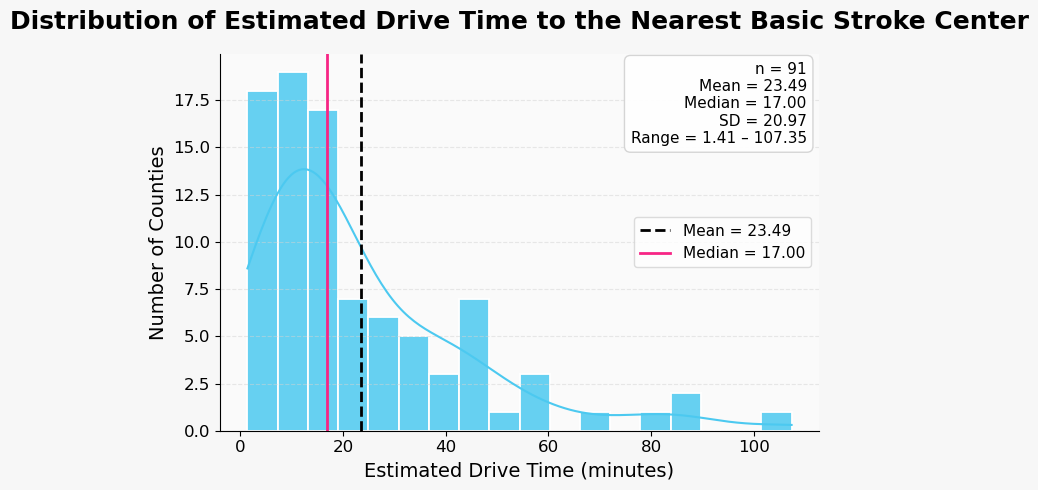

In [177]:
plot_histogram(
    geo,
    column="drive_time_min",
    color=palette["basic"],
    title="Distribution of Estimated Drive Time to the Nearest Basic Stroke Center",
    xlabel="Estimated Drive Time (minutes)"
)

#### Estimated Drive Time to Nearest Advanced Stroke Center

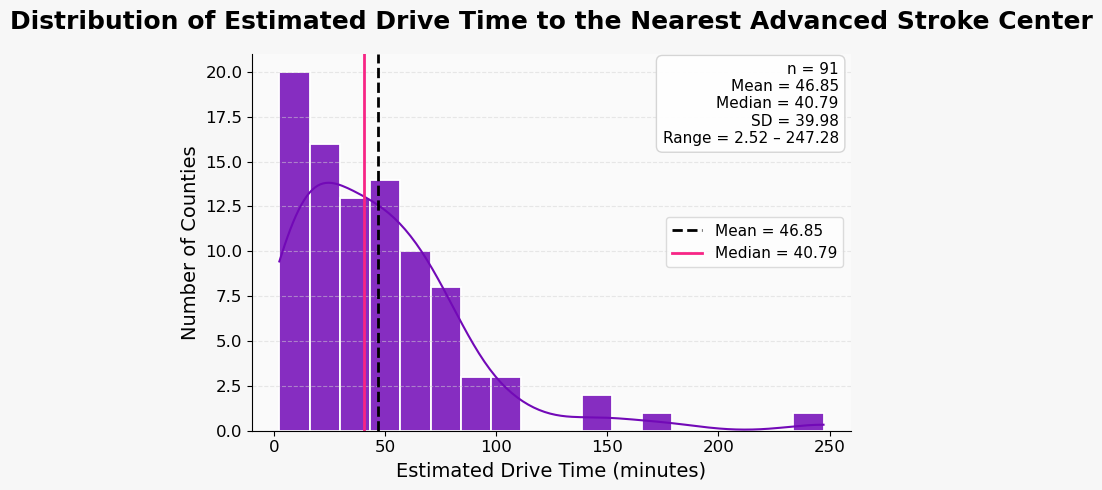

In [180]:
plot_histogram(
    geo,
    column="drive_time_advanced",
    color=palette["advanced"],
    title="Distribution of Estimated Drive Time to the Nearest Advanced Stroke Center",
    xlabel="Estimated Drive Time (minutes)"
)

#### Distance to Nearest Basic Stroke Center

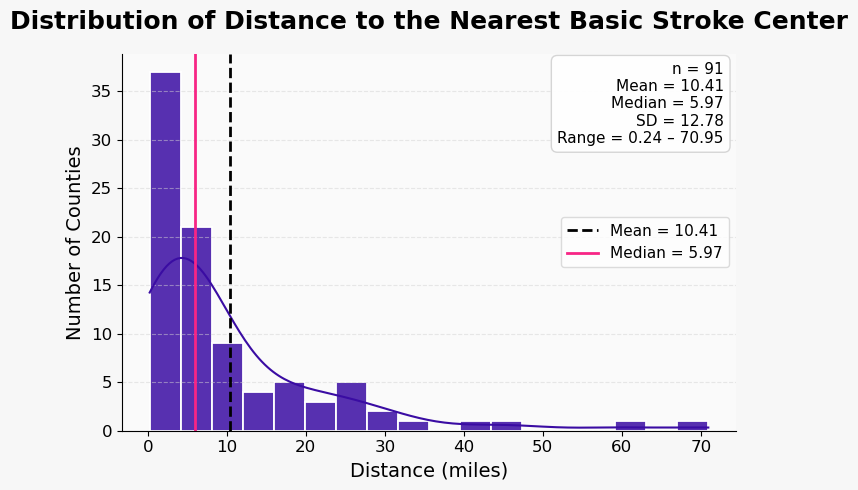

In [183]:
plot_histogram(
    geo,
    column="nearest_stroke_distance",
    color=palette["distance"],
    title="Distribution of Distance to the Nearest Basic Stroke Center",
    xlabel="Distance (miles)" 
)

#### Distance to Nearest Advanced Stroke Center

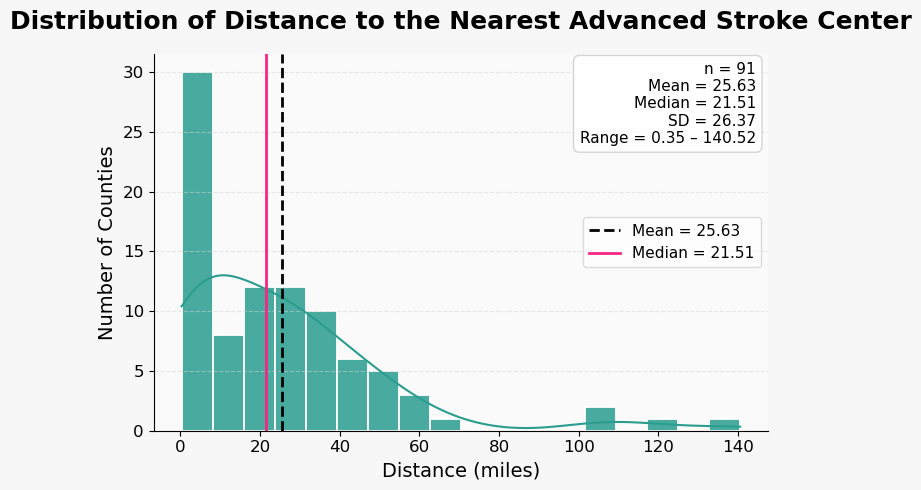

In [186]:
plot_histogram(
    geo,
    column="nearest_stroke_distance_advanced",
    color=palette["advanced_distance"],
    title="Distribution of Distance to the Nearest Advanced Stroke Center",
    xlabel="Distance (miles)" 
)

#### Stroke Mortality

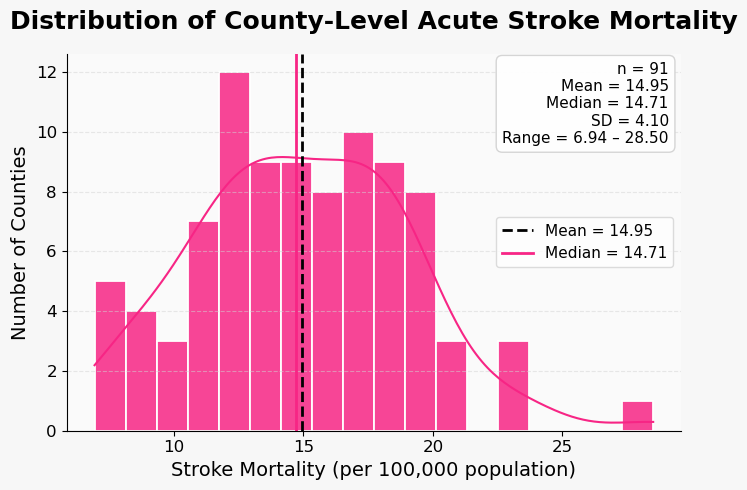

In [189]:
plot_histogram(
    geo,
    column="acute_stroke_mortality_per_100k",
    color=palette["mortality"],
    title="Distribution of County-Level Acute Stroke Mortality",
    xlabel="Stroke Mortality (per 100,000 population)"
)

### Boxplots of Geographic Access Variables

In [220]:
# Creating function to create boxplot of geographic access variables

def plot_boxplot(
    data,
    column,
    color,
    title,
    xlabel
):
    """
    Creates a publication-quality boxplot with
    individual county observations and summary statistics.
    """

    # Summary statistics
    
    mean = data[column].mean()
    median = data[column].median()
    std = data[column].std()

    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    minimum = data[column].min()
    maximum = data[column].max()

    fig, ax = plt.subplots(
        figsize=(8,4),
        facecolor="#F7F7F7"
    )

    ax.set_facecolor("#FAFAFA")

    # Boxplot
    sns.boxplot(
        x=data[column],
        color=color,
        width=0.35,
        linewidth=1.5,
        fliersize=6,
        ax=ax
    )

    # Individual counties
    
    sns.swarmplot(
    x=data[column],
    color="black",
    alpha=0.6,
    size=4,
    ax=ax
    )

    # Mean
    
    ax.scatter(
        mean,
        0,
        marker="D",
        s=80,
        color="white",
        edgecolor="black",
        zorder=5,
        label=f"Mean = {mean:.2f}"
    )

    # Median
    
    ax.axvline(
        median,
        color="#F72585",
        linestyle="--",
        linewidth=2,
        label=f"Median = {median:.2f}"
    )

    # Removing unnecessary borders
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Grid
    
    ax.grid(
        axis="x",
        linestyle="--",
        alpha=0.4
    )

    # Labels
    
    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(
        xlabel,
        fontsize=14
    )

    ax.set_ylabel("")

    ax.tick_params(
        labelsize=12
    )

    # Statistics box
    
    stats_text = (
        f"n = {len(data)}\n"
        f"Mean = {mean:.2f}\n"
        f"Median = {median:.2f}\n"
        f"SD = {std:.2f}\n"
        f"IQR = {iqr:.2f}\n"
        f"Range = {minimum:.2f}–{maximum:.2f}"
    )

    ax.text(
        0.98,
        0.92,
        stats_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(
            facecolor="white",
            edgecolor="lightgray",
            boxstyle="round,pad=0.4"
        )
    )

    # Legend

    ax.legend(
        frameon=True,
        facecolor="white",
        edgecolor="lightgray",
        fontsize=10,
        loc="lower right"
    )

    plt.tight_layout()

    plt.show()

#### Estimated Drive Time to Nearest Basic Stroke Center

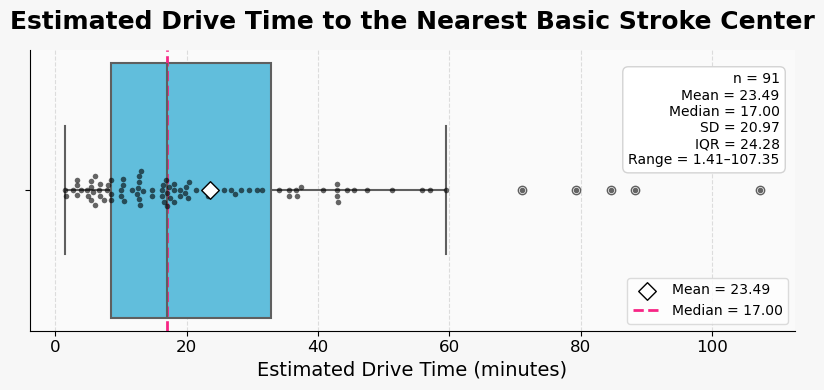

In [223]:
plot_boxplot(
    geo,
    column="drive_time_min",
    color=palette["basic"],
    title="Estimated Drive Time to the Nearest Basic Stroke Center",
    xlabel="Estimated Drive Time (minutes)"
)

#### Estimated Drive Time to Nearest Advanced Stroke Center

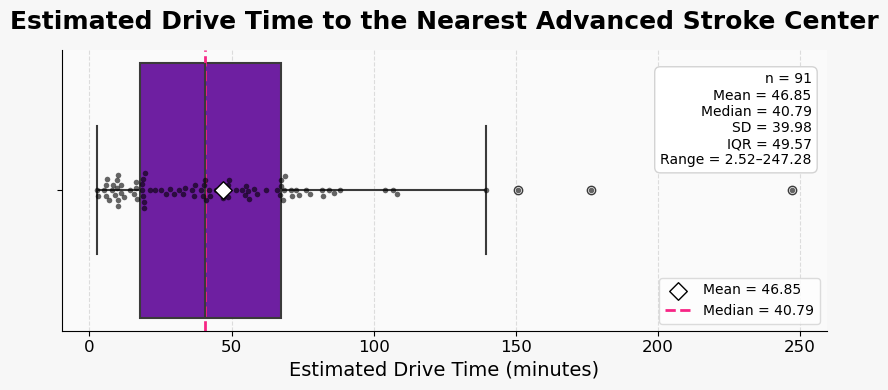

In [226]:
plot_boxplot(
    geo,
    column="drive_time_advanced",
    color=palette["advanced"],
    title="Estimated Drive Time to the Nearest Advanced Stroke Center",
    xlabel="Estimated Drive Time (minutes)"
)

#### Travel Distance to Nearest Basic Stroke Center

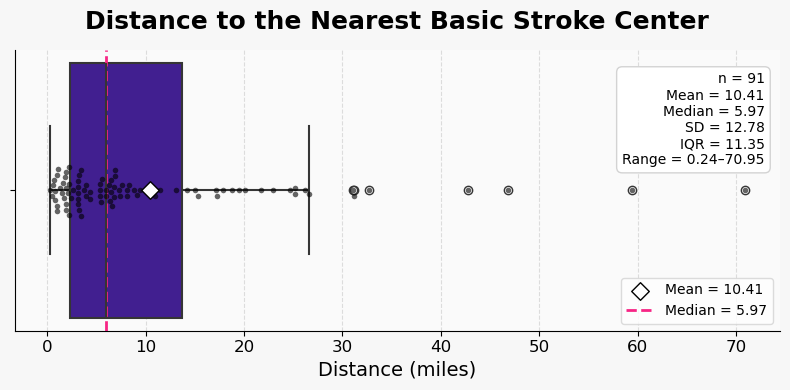

In [229]:
plot_boxplot(
    geo,
    column="nearest_stroke_distance",
    color=palette["distance"],
    title="Distance to the Nearest Basic Stroke Center",
    xlabel="Distance (miles)"
)

#### Distance to Nearest Advanced Stroke Center

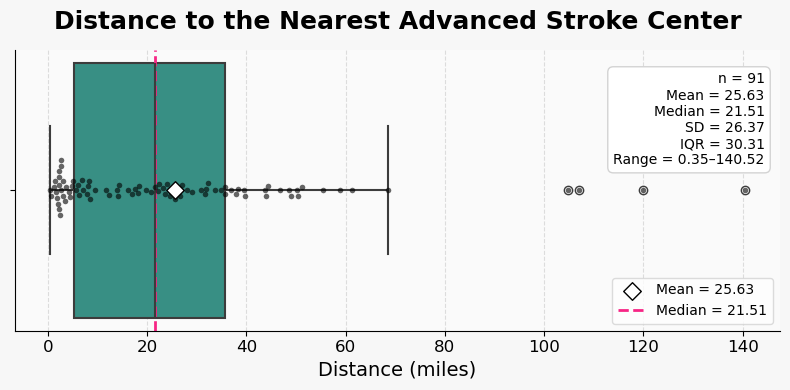

In [232]:
plot_boxplot(
    geo,
    column="nearest_stroke_distance_advanced",
    color=palette["advanced_distance"],
    title="Distance to the Nearest Advanced Stroke Center",
    xlabel="Distance (miles)"
)

#### Stroke Mortality

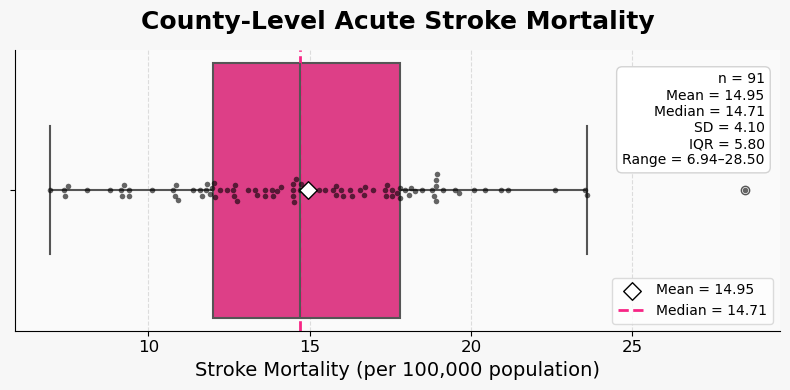

In [235]:
plot_boxplot(
    geo,
    column="acute_stroke_mortality_per_100k",
    color=palette["mortality"],
    title="County-Level Acute Stroke Mortality",
    xlabel="Stroke Mortality (per 100,000 population)"
)

## State-Level Comparisons

In [260]:
# Creating color palette to give each state its own color

state_palette = {
    "NY": "#4CC9F0",
    "NJ": "#7209B7",
    "CT": "#F72585"
}

In [266]:
# Creating a function to create a boxplot comparing all three states

def plot_state_boxplot(
    data,
    column,
    palette,
    title,
    ylabel
    ):
    """
    Publication-quality state comparison boxplot.
    """

    fig, ax = plt.subplots(
        figsize=(10,6),
        facecolor="#F7F7F7"
    )

    ax.set_facecolor("#FAFAFA")

    # Boxplots
    
    sns.boxplot(
        data=data,
        x="state",
        y=column,
        palette=state_palette,
        width=0.55,
        linewidth=1.5,
        fliersize=5,
        ax=ax
    )

    # Individual counties
    
    sns.stripplot(
        data=data,
        x="state",
        y=column,
        palette=state_palette,
        alpha=0.5,
        size=4,
        jitter=0.18,
        ax=ax
    )

    # Grid
    
    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    # Clean borders
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Labels
    
    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        pad=18
    )

    ax.set_xlabel(
        "State",
        fontsize=14
    )

    ax.set_ylabel(
        ylabel,
        fontsize=14
    )

    ax.tick_params(
        labelsize=12
    )

    # Statistics by state
    
    stats = (
        data
        .groupby("state")[column]
        .agg(["mean","median","std"])
        .round(2)
    )

    stats_text = ""

    for state in stats.index:

        stats_text += (
            f"{state}\n"
            f"Mean: {stats.loc[state,'mean']:.2f}\n"
            f"Median: {stats.loc[state,'median']:.2f}\n"
            f"SD: {stats.loc[state,'std']:.2f}\n\n"
        )

    ax.text(
        1.02,
        0.98,
        stats_text,
        transform=ax.transAxes,
        fontsize=10,
        va="top",
        bbox=dict(
            facecolor="white",
            edgecolor="lightgray",
            boxstyle="round,pad=0.4"
        )
    )

    plt.tight_layout()

    plt.show()

### Estimated Drive Time to Basic Stroke Center

C:\Users\janec\AppData\Local\Temp\ipykernel_43864\3122460082.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\janec\AppData\Local\Temp\ipykernel_43864\3122460082.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


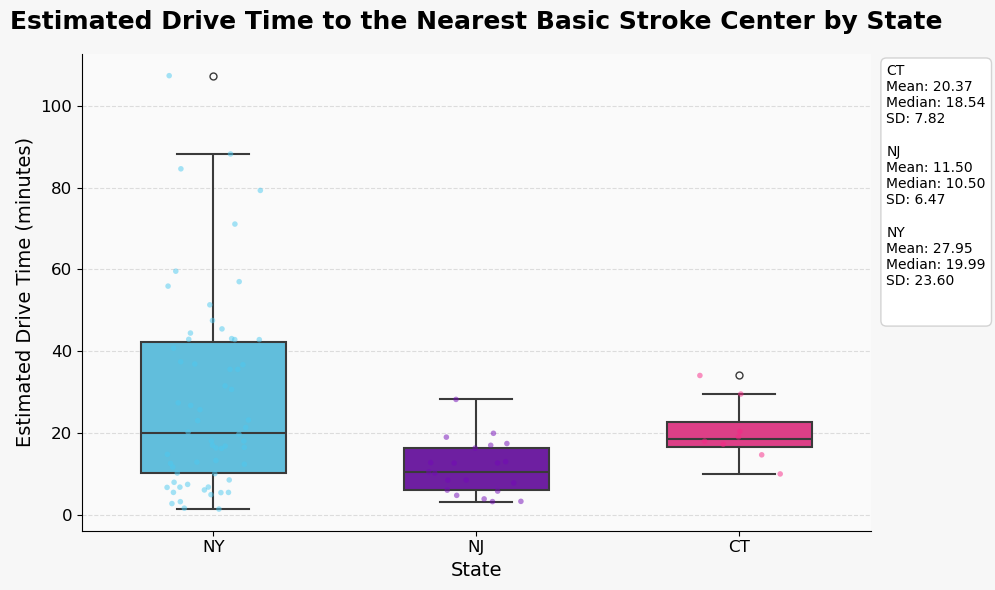

In [271]:
plot_state_boxplot(
    geo,
    column="drive_time_min",
    palette = state_palette,
    title="Estimated Drive Time to the Nearest Basic Stroke Center by State",
    ylabel="Estimated Drive Time (minutes)"
)

### Estimated Drive Time to Advanced Stroke Center

C:\Users\janec\AppData\Local\Temp\ipykernel_43864\3122460082.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\janec\AppData\Local\Temp\ipykernel_43864\3122460082.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


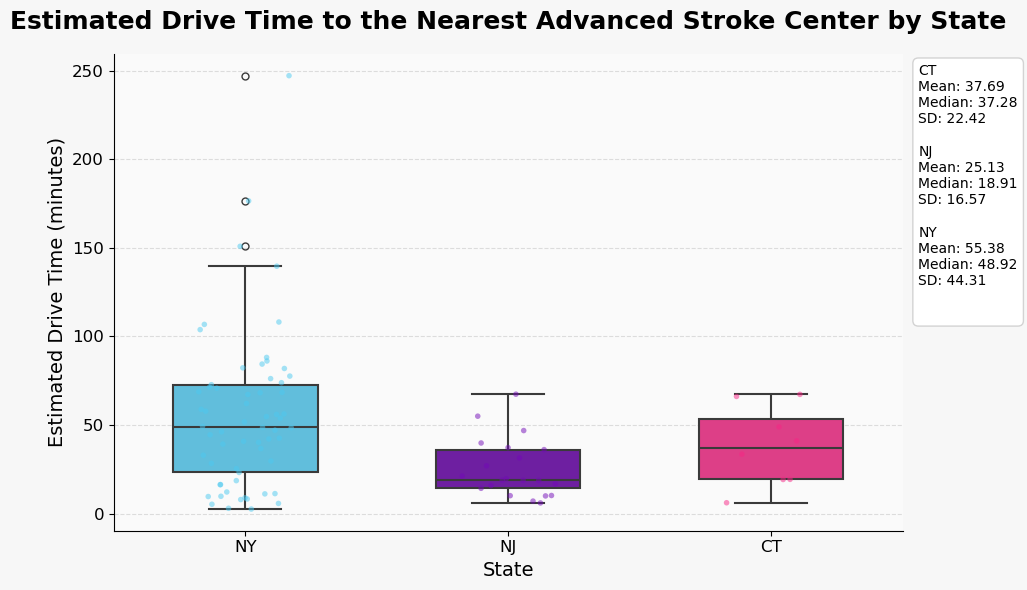

In [273]:
plot_state_boxplot(
    geo,
    column="drive_time_advanced",
    palette=state_palette,
    title="Estimated Drive Time to the Nearest Advanced Stroke Center by State",
    ylabel="Estimated Drive Time (minutes)"
)

### Distance to Nearest Basic Stroke Center

C:\Users\janec\AppData\Local\Temp\ipykernel_43864\3122460082.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\janec\AppData\Local\Temp\ipykernel_43864\3122460082.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


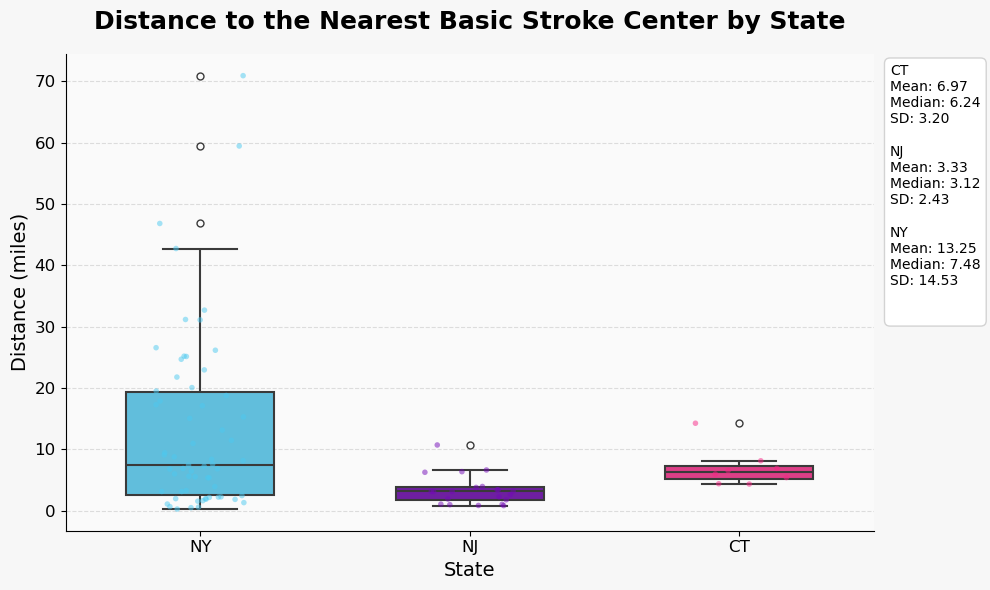

In [275]:
plot_state_boxplot(
    geo,
    column="nearest_stroke_distance",
    palette=state_palette,
    title="Distance to the Nearest Basic Stroke Center by State",
    ylabel="Distance (miles)"
)

### Distance to Nearest Advanced Stroke Center

C:\Users\janec\AppData\Local\Temp\ipykernel_43864\3122460082.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\janec\AppData\Local\Temp\ipykernel_43864\3122460082.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


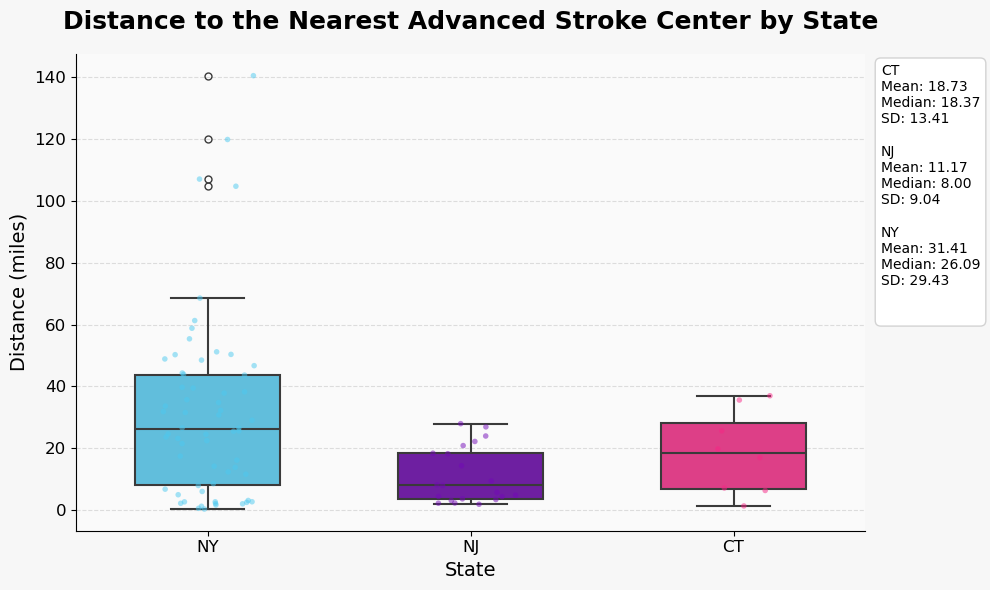

In [277]:
plot_state_boxplot(
    geo,
    column="nearest_stroke_distance_advanced",
    palette=state_palette,
    title="Distance to the Nearest Advanced Stroke Center by State",
    ylabel="Distance (miles)"
)

### Stroke Mortality

C:\Users\janec\AppData\Local\Temp\ipykernel_43864\3122460082.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\janec\AppData\Local\Temp\ipykernel_43864\3122460082.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


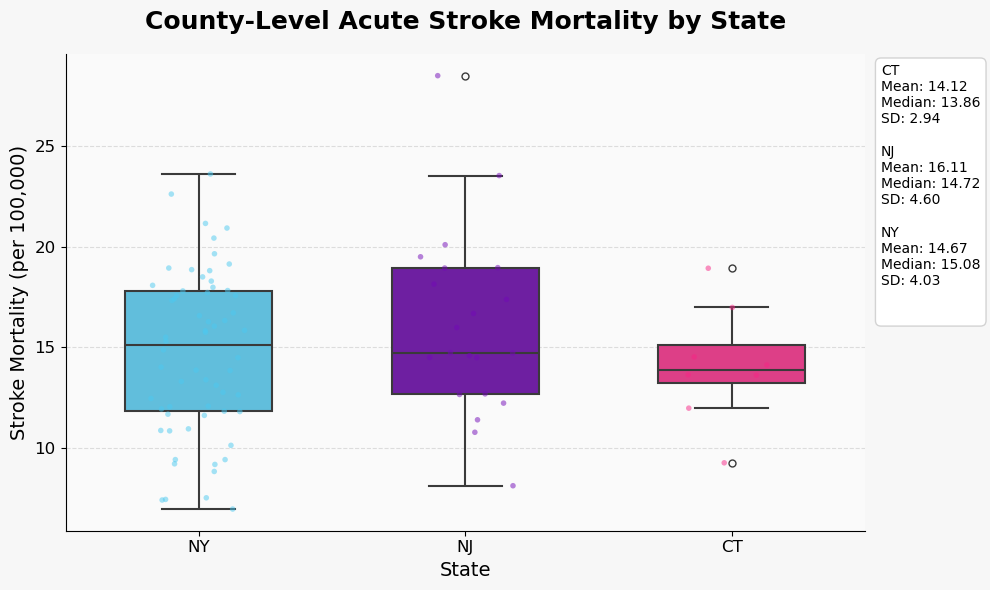

In [279]:
plot_state_boxplot(
    geo,
    column="acute_stroke_mortality_per_100k",
    palette=state_palette,
    title="County-Level Acute Stroke Mortality by State",
    ylabel="Stroke Mortality (per 100,000)"
)

### State Summary Table

In [287]:
# Creating a helper function

def mean_sd(series):
    return f"{series.mean():.1f} ± {series.std():.1f}"

In [299]:
# Building the table

state_summary = pd.DataFrame({
    "Counties": geo.groupby("state").size(),
    "Basic Drive Time\n(min)": geo.groupby("state")["drive_time_min"].apply(mean_sd),
    "Advanced Drive Time\n(min)": geo.groupby("state")["drive_time_advanced"].apply(mean_sd),
    "Basic Distance\n(miles)": geo.groupby("state")["nearest_stroke_distance"].apply(mean_sd),
    "Advanced Distance\n(miles)": geo.groupby("state")["nearest_stroke_distance_advanced"].apply(mean_sd),
    "Stroke Mortality\n(per 100k)": geo.groupby("state")["acute_stroke_mortality_per_100k"].apply(mean_sd)
})

state_summary.index.name = "State"

In [301]:
(
    state_summary.style
    .set_caption("Table 1. State-Level Summary Statistics for Geographic Accessibility and Stroke Mortality (Mean ± SD)")
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "16px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("padding-bottom", "12px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("background-color", "#3A0CA3"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("text-align", "center")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "center"),
                ("padding", "8px")
            ]
        }
    ])
    .set_properties(**{
        "background-color": "#FAFAFA",
        "border": "1px solid lightgray"
    })
)

,Counties,Basic Drive Time (min),Advanced Drive Time (min),Basic Distance (miles),Advanced Distance (miles),Stroke Mortality (per 100k)
State,,,,,,
CT,8,20.4 ± 7.8,37.7 ± 22.4,7.0 ± 3.2,18.7 ± 13.4,14.1 ± 2.9
NJ,21,11.5 ± 6.5,25.1 ± 16.6,3.3 ± 2.4,11.2 ± 9.0,16.1 ± 4.6
NY,62,28.0 ± 23.6,55.4 ± 44.3,13.3 ± 14.5,31.4 ± 29.4,14.7 ± 4.0


**Interpretation**

Several differences in geographic accessibility are evident across the three states. Counties in Connecticut generally exhibit shorter travel times and distances to stroke centers, reflecting the state's smaller geographic area and relatively dense distribution of certified stroke centers. In contrast, New York demonstrates the greatest variability in accessibility, with rural counties experiencing substantially longer travel times and distances than urban counties. New Jersey generally falls between Connecticut and New York for most accessibility measures. Differences between Basic and Advanced Stroke Center accessibility are also apparent, with travel times and distances to Advanced Stroke Centers consistently exceeding those to Basic Stroke Centers, reflecting the more limited availability of advanced stroke care facilities.

## Relationship Between Geographic Accessibility Variables

The following scatterplots examine the relationship between straight-line distance and estimated driving time to the nearest Basic and Advanced Stroke Centers. A strong positive linear relationship is expected, as counties located farther from certified stroke centers should generally require longer travel times. Pearson correlation coefficients are reported to quantify the strength of these associations.

In [306]:
# Importing neccessary libraries

from scipy.stats import pearsonr

In [308]:
# Creating a function to create a scatterplot 

def plot_scatter(
    data,
    x,
    y,
    color,
    title,
    xlabel,
    ylabel
):
    """
    Publication-quality scatterplot with regression line and
    Pearson correlation coefficient.
    """

    r, p = pearsonr(data[x], data[y])

    fig, ax = plt.subplots(
        figsize=(10,7),
        facecolor="#F7F7F7"
    )

    ax.set_facecolor("#FAFAFA")

    sns.regplot(
        data=data,
        x=x,
        y=y,
        scatter_kws={
            "s":70,
            "alpha":0.75,
            "color":color,
            "edgecolor":"white"
        },
        line_kws={
            "color":"black",
            "linewidth":2
        },
        ax=ax
    )

    ax.grid(
        linestyle="--",
        alpha=0.4
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        pad=18
    )

    ax.set_xlabel(
        xlabel,
        fontsize=14
    )

    ax.set_ylabel(
        ylabel,
        fontsize=14
    )

    ax.tick_params(labelsize=12)

    stats_text = (
        f"Pearson r = {r:.3f}\n"
        f"p-value < {p:.3g}\n"
        f"n = {len(data)}"
    )

    ax.text(
        0.98,
        0.05,
        stats_text,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=11,
        bbox=dict(
            facecolor="white",
            edgecolor="lightgray",
            boxstyle="round,pad=0.4"
        )
    )

    plt.tight_layout()

    plt.show()

### Distance to Basic Stroke Center vs. Estimated Drive Time to Basic Stroke Center

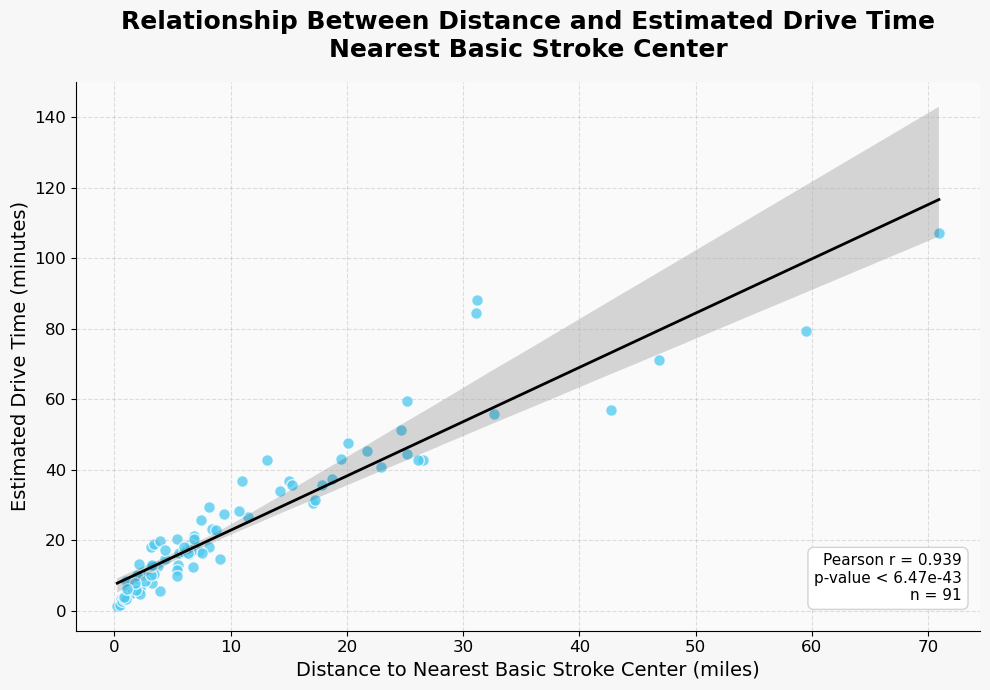

In [313]:
plot_scatter(
    geo,
    x="nearest_stroke_distance",
    y="drive_time_min",
    color=palette["basic"],
    title="Relationship Between Distance and Estimated Drive Time\nNearest Basic Stroke Center",
    xlabel="Distance to Nearest Basic Stroke Center (miles)",
    ylabel="Estimated Drive Time (minutes)"
)

### Distance to Advanced Stroke Center vs. Estimated Drive Time to Advanced Stroke Center

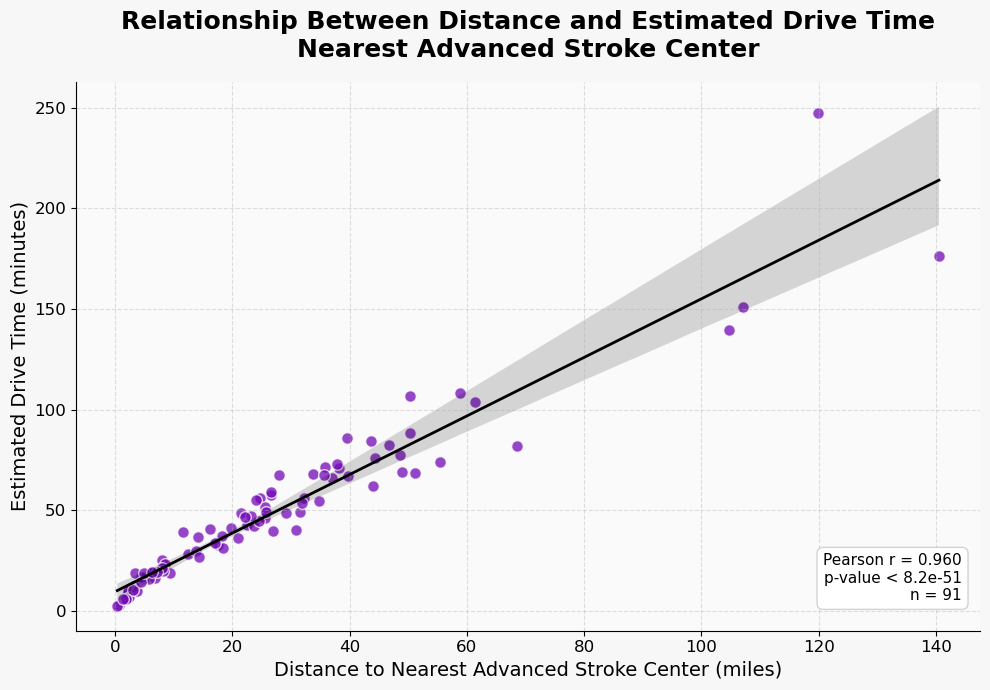

In [316]:
plot_scatter(
    geo,
    x="nearest_stroke_distance_advanced",
    y="drive_time_advanced",
    color=palette["advanced"],
    title="Relationship Between Distance and Estimated Drive Time\nNearest Advanced Stroke Center",
    xlabel="Distance to Nearest Advanced Stroke Center (miles)",
    ylabel="Estimated Drive Time (minutes)"
)

### Correlation Matrix

In [328]:
# Importing neccessary libraries

from matplotlib.colors import LinearSegmentedColormap

In [320]:
# Computing correlations

corr = geo[
    [
        "acute_stroke_mortality_per_100k",
        "drive_time_min",
        "drive_time_advanced",
        "nearest_stroke_distance",
        "nearest_stroke_distance_advanced"
    ]
].corr()

In [324]:
# Creating labels for correlation heatmap

labels = [
    "Stroke\nMortality",
    "Basic\nDrive Time",
    "Advanced\nDrive Time",
    "Basic\nDistance",
    "Advanced\nDistance"
]

In [332]:
# Creating custom color palette for heatmap

custom_cmap = LinearSegmentedColormap.from_list(
    "project",
    [
        "#F7F7F7",  
        "#4CC9F0",  
        "#7209B7",  
        "#3A0CA3"   
    ]
)

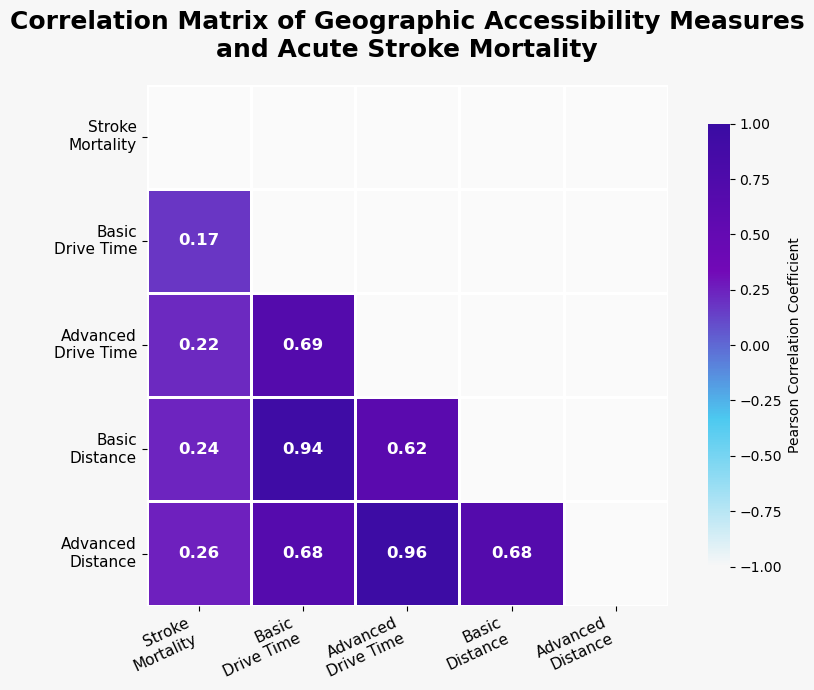

In [334]:
# Constructing correlation heatmap 

# Only using upper triangle (non-redundant values)

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(
    figsize=(9,7),
    facecolor="#F7F7F7"
)

ax.set_facecolor("#FAFAFA")

sns.heatmap(
    corr,
    mask=mask,
    cmap=custom_cmap,
    annot=True,
    fmt=".2f",
    annot_kws={
        "fontsize":12,
        "fontweight":"bold"
    },
    linewidths=2,
    linecolor="white",
    square=True,
    vmin=-1,
    vmax=1,
    center=0,
    cbar_kws={
        "label":"Pearson Correlation Coefficient",
        "shrink":0.85
    },
    ax=ax
)

ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=11)
ax.set_yticklabels(labels, rotation=0, fontsize=11)

plt.title(
    "Correlation Matrix of Geographic Accessibility Measures\nand Acute Stroke Mortality",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()

plt.show()

The correlation matrix summarizes the pairwise relationships among all geographic accessibility measures and acute stroke mortality. Strong positive correlations between distance- and time-based accessibility metrics would indicate that these variables capture similar aspects of geographic access, while correlations with stroke mortality provide an initial assessment of whether reduced accessibility is associated with poorer health outcomes. 

The correlation analysis revealed a **weak positive** association between **acute stroke mortality** and **geographic accessibility measures**. Among the four accessibility variables, distance to the nearest Advanced Stroke Center exhibited the strongest relationship with stroke mortality (r = 0.26). This finding suggests that counties located farther from Advanced Stroke Centers tend to experience slightly higher stroke mortality rates.

However, the strength of this relationship is modest, indicating that geographic accessibility alone explains only a small proportion of the variation in stroke mortality. Stroke outcomes are influenced by numerous factors beyond physical access to care, including demographic characteristics, socioeconomic conditions, underlying disease burden, emergency medical services, and hospital quality. Consequently, these findings suggest that geographic accessibility represents one important component of stroke outcomes but should be interpreted alongside other determinants of health.

## Geographic Accessibility vs. Stroke Mortality

The following scatterplots explore the relationship between county-level geographic accessibility to stroke care and acute stroke mortality. Each point represents one county within New York, New Jersey, or Connecticut. Linear regression lines with 95% confidence intervals are included to visualize the overall trend, while Pearson correlation coefficients quantify the strength of the linear association. Although stronger geographic accessibility is expected to be associated with lower stroke mortality, these exploratory analyses provide only unadjusted relationships and do not account for demographic, socioeconomic, or healthcare system factors that may also influence mortality.

In [377]:
# Creating function to create scatterplot

def mortality_scatter(
    data,
    x,
    color,
    title,
    xlabel
):
    """
    Publication-quality scatterplot comparing an accessibility
    measure with acute stroke mortality.
    """

    y = "acute_stroke_mortality_per_100k"

    r, p = pearsonr(data[x], data[y])
    r2 = r**2

    fig, ax = plt.subplots(
        figsize=(10,7),
        facecolor="#F7F7F7"
    )

    ax.set_facecolor("#FAFAFA")

    # Regression line

    sns.regplot(
    data=data,
    x=x,
    y=y,
    scatter=False,
    ci=95,
    line_kws={
        "color": "black",
        "linewidth": 2
    },
    ax=ax
    )

# Scatter points colored by state

    sns.scatterplot(
    data=data,
    x=x,
    y=y,
    hue="state",
    palette=state_palette,
    s=70,
    alpha=0.8,
    edgecolor="white",
    linewidth=0.8,
    ax=ax
    )

    # Creating legend for state

    ax.legend(
    title="State",
    frameon=True,
    facecolor="white",
    edgecolor="lightgray",
    fontsize=11,
    title_fontsize=12,
    loc="upper left"
)



    ax.grid(
        linestyle="--",
        alpha=0.4
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_title(
        title,
        fontsize=18,
        fontweight="bold",
        pad=18
    )

    ax.set_xlabel(
        xlabel,
        fontsize=14
    )

    ax.set_ylabel(
        "Acute Stroke Mortality\n(per 100,000 population)",
        fontsize=14
    )

    ax.tick_params(labelsize=12)

    stats = (
        f"Pearson r = {r:.3f}\n"
        f"$R^2$ = {r2:.3f}\n"
        f"p = {p:.3f}\n"
        f"n = {len(data)}"
    )

    ax.text(
        0.98,
        0.04,
        stats,
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=11,
        bbox=dict(
            facecolor="white",
            edgecolor="lightgray",
            boxstyle="round,pad=0.4"
        )
    )

    plt.tight_layout()

    plt.show()

### Estimated Drive Time to Basic Stroke Center vs. Stroke Mortality

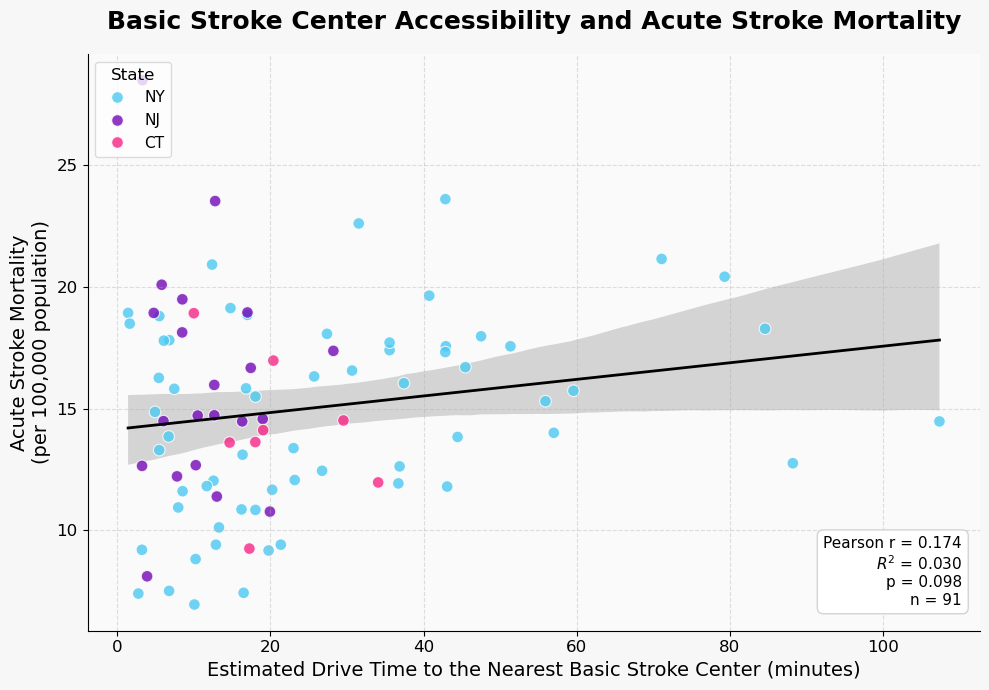

In [380]:
mortality_scatter(
    geo,
    x="drive_time_min",
    color=palette["basic"],
    title="Basic Stroke Center Accessibility and Acute Stroke Mortality",
    xlabel="Estimated Drive Time to the Nearest Basic Stroke Center (minutes)"
)

### Estimated Drive Time to Advanced Stroke Center vs. Stroke Mortality

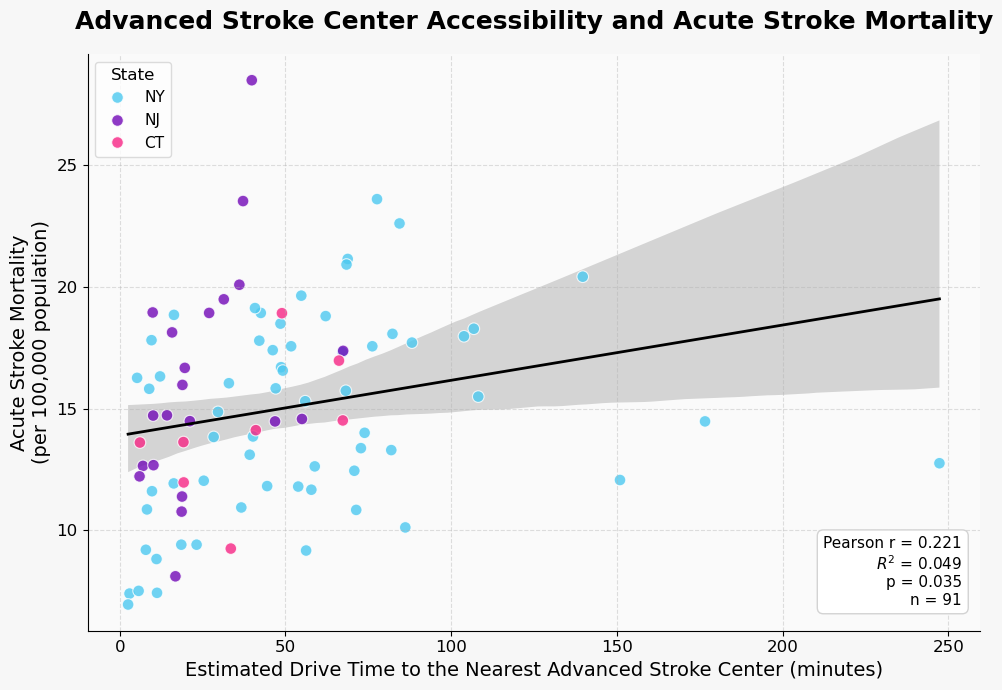

In [382]:
mortality_scatter(
    geo,
    x="drive_time_advanced",
    color=palette["advanced"],
    title="Advanced Stroke Center Accessibility and Acute Stroke Mortality",
    xlabel="Estimated Drive Time to the Nearest Advanced Stroke Center (minutes)"
)

### Distance to Nearest Basic Stroke Center vs. Stroke Mortality

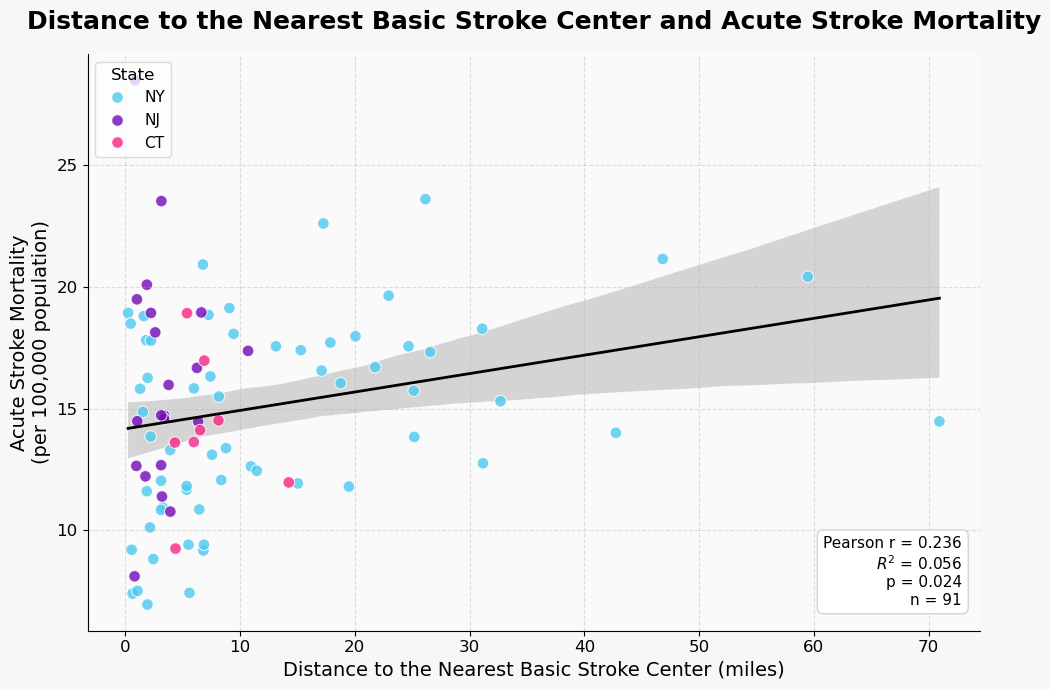

In [385]:
mortality_scatter(
    geo,
    x="nearest_stroke_distance",
    color=palette["distance"],
    title="Distance to the Nearest Basic Stroke Center and Acute Stroke Mortality",
    xlabel="Distance to the Nearest Basic Stroke Center (miles)"
)

### Distance to Nearest Advanced Stroke Center vs. Mortality

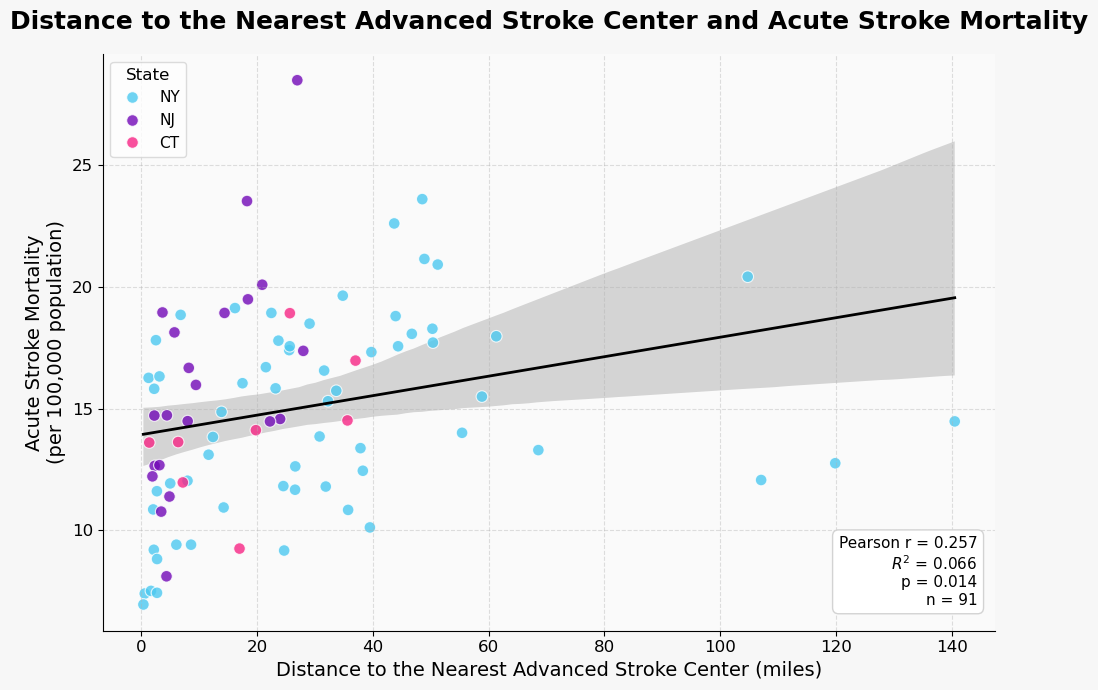

In [388]:
mortality_scatter(
    geo,
    x="nearest_stroke_distance_advanced",
    color=palette["advanced_distance"],
    title="Distance to the Nearest Advanced Stroke Center and Acute Stroke Mortality",
    xlabel="Distance to the Nearest Advanced Stroke Center (miles)"
)

## County Rankings

In [457]:
# Import neccessary libraries

from IPython.display import display, HTML

In [552]:
# Creating a function to display geographic accessiblity measure for top/bottom counties

def county_rankings(
    data,
    column,
    title,
    unit,
    n=10,
):
    """
    Displays the top and bottom n counties side-by-side.
    """

    best = (
        data[["county", "state", column]]
        .sort_values(column)
        .head(n)
        .reset_index(drop=True)
    )

    best.index = best.index + 1
    best.rename(columns={column: unit}, inplace=True)

    worst = (
        data[["county", "state", column]]
        .sort_values(column, ascending=False)
        .head(n)
        .reset_index(drop=True)
    )

    worst.index = worst.index + 1
    worst.rename(columns={column: unit}, inplace=True)

    best_html = (
        best.style
        .hide(axis="index")
        .format({unit: "{:.2f}"})
        .set_caption("Top 10 Counties (Best Accessibility)")
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("font-size", "14px"),
                    ("font-weight", "bold"),
                    ("text-align", "center")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#3A0CA3"),
                    ("color", "white"),
                    ("font-weight", "bold")
                ]
            }
        ])
        .to_html()
    )

    worst_html = (
        worst.style
        .hide(axis="index")
        .format({unit: "{:.2f}"})
        .set_caption("Top 10 Counties (Worst Accessibility)")
        .set_table_styles([
            {
                "selector": "caption",
                "props": [
                    ("font-size", "14px"),
                    ("font-weight", "bold"),
                    ("text-align", "center")
                ]
            },
            {
                "selector": "th",
                "props": [
                    ("background-color", "#F72585"),
                    ("color", "white"),
                    ("font-weight", "bold")
                ]
            }
        ])
        .to_html()
    )

    display(HTML(f"""
    <h3>{title}</h3>

    <div style="
    display:flex;
    justify-content:center;
    align-items:flex-start;
    gap:12px;
    ">
        <div style="width:48%;">
            {best_html}
        </div>

        <div style="width:48%;">
            {worst_html}
        </div>
    </div>
    """))

### Estimated Drive Time to Nearest Basic Stroke Center

In [555]:
county_rankings(
    geo,
    column="drive_time_min",
    title="Estimated Drive Time to the Nearest Basic Stroke Center",
    unit="Drive Time (min)"
)

county,state,Drive Time (min)
Cayuga,NY,1.41
Genesee,NY,1.63
Kings,NY,2.75
Bronx,NY,3.22
Essex,NJ,3.24
Cape May,NJ,3.30
Hudson,NJ,3.89
Burlington,NJ,4.76
Schenectady,NY,4.93
Broome,NY,5.43


### Estimated Drive Time to Nearest Advanced Stroke Center

In [558]:
county_rankings(
    geo,
    column="drive_time_advanced",
    title="Estimated Drive Time to the Nearest Advanced Stroke Center",
    unit="Drive Time (min)"
)

county,state,Drive Time (min)
New York,NY,2.52
Kings,NY,2.95
Broome,NY,5.23
Queens,NY,5.70
Passaic,NJ,5.98
Hartford,CT,6.08
Essex,NJ,7.00
Bronx,NY,7.88
Westchester,NY,8.21
Onondaga,NY,8.89


### Distance to Nearest Basic Stroke Center

In [561]:
county_rankings(
    geo,
    column="nearest_stroke_distance",
    title="Distance to the Nearest Basic Stroke Center",
    unit="Distance (miles)"
)

county,state,Distance (miles)
Cayuga,NY,0.24
Genesee,NY,0.47
Bronx,NY,0.55
Kings,NY,0.63
Hudson,NJ,0.80
Cape May,NJ,0.83
Essex,NJ,0.96
Ocean,NJ,1.01
Somerset,NJ,1.04
Queens,NY,1.06


### Distance to Nearest Advanced Stroke Center

In [564]:
county_rankings(
    geo,
    column="nearest_stroke_distance_advanced",
    title="Distance to the Nearest Advanced Stroke Center",
    unit="Distance (miles)"
)

county,state,Distance (miles)
New York,NY,0.35
Kings,NY,0.59
Broome,NY,1.25
Hartford,CT,1.36
Queens,NY,1.66
Passaic,NJ,1.91
Westchester,NY,2.04
Bronx,NY,2.15
Onondaga,NY,2.21
Bergen,NJ,2.24
